# Project description
Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions
1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset.
4. Test the data using the test sample and provide a conclusion.

## Data description
The data is stored in the `taxi.csv` file.  
The number of orders is in the `num_orders` column.

## Data preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import seasonal_decompose
 
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, make_scorer 

from sklearn.linear_model import LinearRegression   
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [2]:
#df = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
#df = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])
df = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', index_col=[0], parse_dates=[0])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
print('Available dates: ',df.index.min(),' - ', df.index.max())

Available dates:  2018-03-01 00:00:00  -  2018-08-31 23:50:00


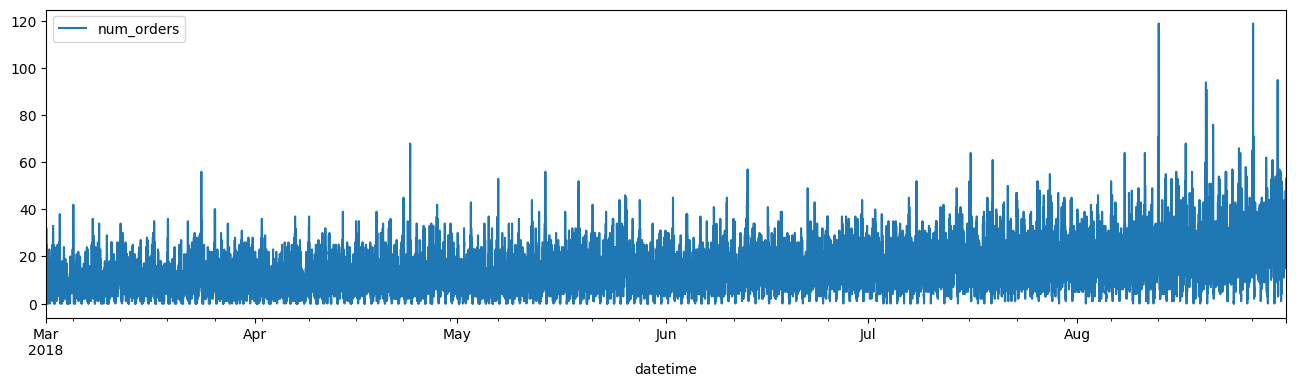

In [6]:
#data every 10 minutes
df.plot(figsize=(16,4))
plt.show()

**Data Description**
- `datetime` - date and time of sampling
- `num_orders` - number of taxi orders

Data is available from March 1, 2018, to August 31, 2018.

There are no missing values.

The data is sampled every 10 minutes, but the analysis requires hourly data.

## Analysis
Resampling per hour

In [7]:
# check that the dates are in order
df.index.is_monotonic_increasing

True

In [8]:
# resample per hour
df = df.resample('1h').sum()
df.head(3)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71


In [9]:
# create column with moving average with window size of 6 hours
df['rolling_mean_6'] = df['num_orders'].shift().rolling(6).mean()
df.sample(3)

,num_orders,rolling_mean_6
datetime,,
2018-03-15 14:00:00,64,52.166667
2018-06-04 07:00:00,20,76.500000
2018-07-21 06:00:00,33,130.500000


**Influence of time on the number of orders**

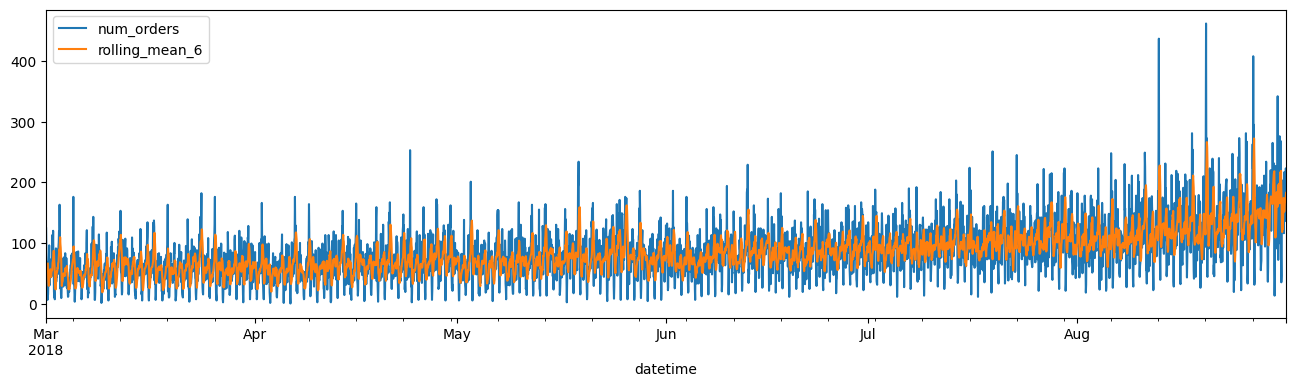

In [10]:
df.plot(figsize=(16,4))
plt.show()

Decompose the data into trend, seasonal component and residuals

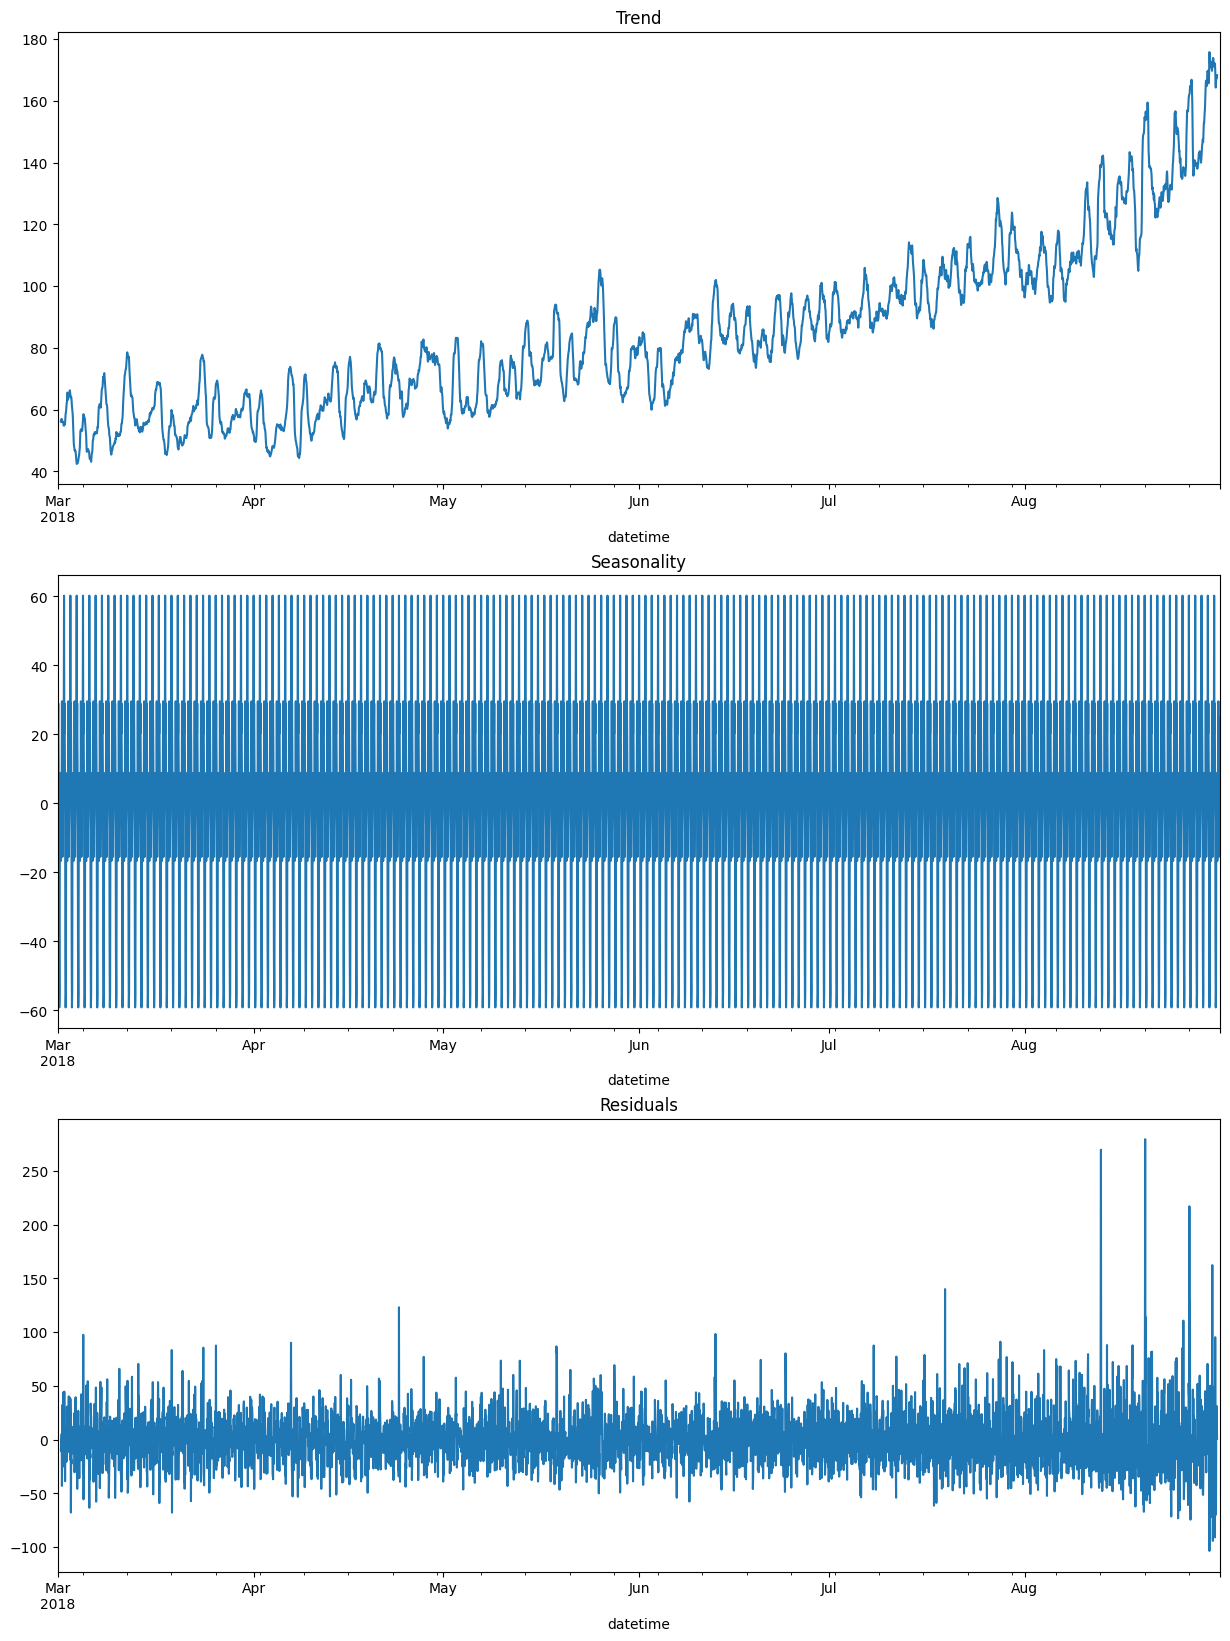

In [11]:
decomposed = seasonal_decompose(df['num_orders'])

plt.figure(figsize=(15, 20))  

plt.subplot(311) #3 rows, 1 col - 1st graph
decomposed.trend.plot(ax=plt.gca())  # plt.gca() --> Get the current Axes 
plt.title('Trend')  

plt.subplot(312)  
decomposed.seasonal.plot(ax=plt.gca()) 
plt.title('Seasonality')  

plt.subplot(313)  
decomposed.resid.plot(ax=plt.gca())  
plt.title('Residuals') 

plt.show()

The first graph shows a positive trend, as the number of taxi requests increases over the months.

The seasonal component fluctuates around zero; no clearly repeating pattern is evident, so a longer period would be necessary to identify a well-defined seasonality.

The residual or noise graph shows some outliers, with a notable increase in variability during the month of August.

In [12]:
# exploration per hour
df.groupby(df.index.hour)['num_orders'].describe()

,count,mean,std,min,25%,50%,75%,max
datetime,,,,,,,,
0,184.0,144.402174,49.224380,42.0,104.00,142.0,167.50,281.0
1,184.0,104.364130,47.611853,33.0,73.00,93.5,124.25,273.0
2,184.0,113.070652,65.815443,20.0,68.75,104.5,146.00,462.0
3,184.0,102.021739,44.282125,24.0,68.00,96.5,128.00,267.0
4,184.0,86.907609,52.755930,15.0,43.00,83.0,117.00,295.0
5,184.0,42.630435,26.754997,1.0,20.75,37.5,61.25,121.0
6,184.0,25.173913,21.288345,0.0,9.00,19.0,35.00,95.0
7,184.0,29.271739,15.869759,5.0,18.00,27.0,38.00,103.0
8,184.0,73.048913,24.663258,25.0,58.00,71.5,85.00,182.0


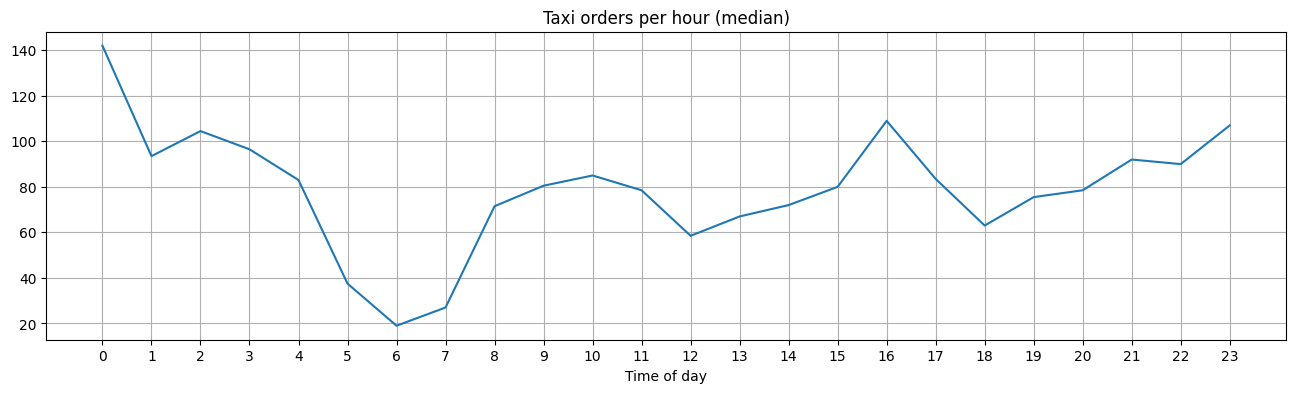

In [13]:
df.groupby(df.index.hour)['num_orders'].median().plot(figsize=(16,4))
plt.xticks(ticks=range(24), labels=range(24))
plt.xlabel("Time of day")
plt.title("Taxi orders per hour (median)")
plt.grid(True)
plt.show()

The fewest taxis are required around 6 and 7 a.m.

The highest number of taxis is required between 11 p.m. and 3 a.m. This trend is similar to that at 4 p.m.

**Influence of the month on the number of requests**

In [14]:
# Monthly Values ​​Exploration (ME: month end)
#df.resample('M')['num_orders'].describe()  # DEPRECATED
df['num_orders'].resample('ME').agg(['count', 'mean', 'std', 'min', 'max', 'sum'])


,count,mean,std,min,max,sum
datetime,,,,,,
2018-03-31,744,57.483871,29.562439,1,182,42768
2018-04-30,720,63.804167,32.036301,0,253,45939
2018-05-31,744,73.682796,34.849825,2,234,54820
2018-06-30,720,83.202778,32.826776,6,229,59906
2018-07-31,744,100.006720,37.254770,11,251,74405
2018-08-31,744,127.651882,56.242228,13,462,94973


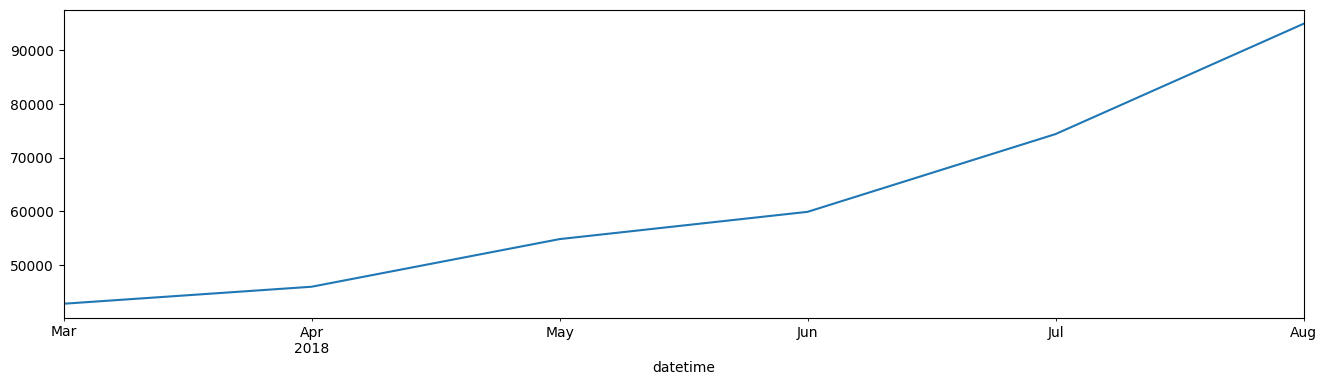

In [15]:
# Exploration per month
df['num_orders'].resample('ME').sum().plot(figsize=(16,4))
plt.show()

Throughout the year, the number of taxi requests shows an upward trend.

In August, the most recent month recorded, the number of requests doubled compared to March, the previous month.

## Training

Features are created for forecasting, and different models are trained with different hyperparameters.

**Create Features for Forecasting**

The following features are created for predictive models, except for the constant model.
- Calendar features: month, day of the month, and day of the week
- Lag features: uses past values ​​to determine whether orders will increase or decrease
- Moving average feature: establishes the overall trend of the time series

In [16]:
df['month'] = df.index.month
#df['week'] = df.index.isocalendar().week
df['day'] =   df.index.day
df['dayofweek'] = df.index.dayofweek
df['hour'] =  df.index.hour

In [17]:
max_lag = 5

for lag in range(1, max_lag + 1):
    df['lag_{}'.format(lag)] = df['num_orders'].shift(lag) 

In [18]:
df.head(10)

,num_orders,rolling_mean_6,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5
datetime,,,,,,,,,,,
2018-03-01 00:00:00,124,NaN,3,1,3,0,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,NaN,3,1,3,1,124.0,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,NaN,3,1,3,2,85.0,124.0,NaN,NaN,NaN
2018-03-01 03:00:00,66,NaN,3,1,3,3,71.0,85.0,124.0,NaN,NaN
2018-03-01 04:00:00,43,NaN,3,1,3,4,66.0,71.0,85.0,124.0,NaN
2018-03-01 05:00:00,6,NaN,3,1,3,5,43.0,66.0,71.0,85.0,124.0
2018-03-01 06:00:00,12,65.833333,3,1,3,6,6.0,43.0,66.0,71.0,85.0
2018-03-01 07:00:00,15,47.166667,3,1,3,7,12.0,6.0,43.0,66.0,71.0
2018-03-01 08:00:00,34,35.500000,3,1,3,8,15.0,12.0,6.0,43.0,66.0


**Separate data into training and test sets**

The test sample is made up of 10% of the initial data set.

In [19]:
df = df.dropna() 

In [20]:
features = df.drop(['num_orders'],axis=1)
target = df['num_orders']

# split data
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.1, shuffle=False)

In [21]:
print('train shape: ', features_train.shape)
print('test shape: ', features_test.shape)

train shape:  (3969, 10)
test shape:  (441, 10)


In [22]:
# verify that training data set is from dates prior to test data set
print('Date range of the training set: ', features_train.index.min(),' - ', features_train.index.max()) 
print('Date range of the test set:     ', features_test.index.min(), ' - ',features_test.index.max()) 

Date range of the training set:  2018-03-01 06:00:00  -  2018-08-13 14:00:00
Date range of the test set:      2018-08-13 15:00:00  -  2018-08-31 23:00:00


### Constant Predictive Model

All values ​​in the test sample are predicted with the same number (a constant), which is the median of the training data set.

In [23]:
print('Median number of taxi orders per hour:',df['num_orders'].median())

Median number of taxi orders per hour: 78.0


### Linear Regression

In [24]:
model_lr = LinearRegression()
model_lr.fit(features_train, target_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Decision Tree Regressor

In [25]:
param_grid = {'max_depth': [1,2,4,6,8,10]}

tree_reg = DecisionTreeRegressor(random_state=12345)
grid_search_dtr = GridSearchCV(estimator=tree_reg, param_grid=param_grid, cv=TimeSeriesSplit(n_splits = 3), verbose=True, 
                               scoring='neg_root_mean_squared_error')
grid_search_dtr.fit(features_train, target_train)


model_dtr = grid_search_dtr.best_estimator_
model_dtr.fit(features_train, target_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,12345
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Random Forest Regressor

In [26]:
param_grid = {'n_estimators': [1,2,3,4,6,8,10],'max_features': [ 'sqrt', 'log2'],'max_depth' : [2,3,4,5,6,8,10]}

model_rfr =RandomForestRegressor(random_state=12345)
grid_search_rfr = GridSearchCV(estimator=model_rfr, param_grid=param_grid, cv=TimeSeriesSplit(n_splits = 3), scoring='neg_root_mean_squared_error')

grid_search_rfr.fit(features_train, target_train)


model_rfr = grid_search_rfr.best_estimator_
model_rfr.fit(features_train, target_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### CatBoost Regressor

In [27]:
param_cb={'depth':[4, 6, 8, 10], 'learning_rate':[0.5, 0.1], 'iterations':[10, 30, 50, 100], 'loss_function':['RMSE']}

model_cb = CatBoostRegressor(random_seed=123456, verbose=False)
grid_search_cat = GridSearchCV(estimator=model_cb, param_grid=param_cb, cv=TimeSeriesSplit(n_splits = 3), n_jobs=-1, scoring='neg_root_mean_squared_error')

grid_search_cat.fit(features_train, target_train)
print(grid_search_cat.best_params_)

model_cbr = grid_search_cat.best_estimator_
model_cbr.fit(features_train, target_train)

{'depth': 4, 'iterations': 100, 'learning_rate': 0.5, 'loss_function': 'RMSE'}


### LGBM Regressor

In [28]:
param_ltb={'num_leaves':[10, 15, 20], 'learning_rate':[0.5, 0.1], 'n_estimators':[10, 20, 30], 'objective':['rmse']}

model_ltb = LGBMRegressor(random_seed=123456)
grid_search_LGBM = GridSearchCV(estimator=model_ltb, param_grid=param_ltb, cv=TimeSeriesSplit(n_splits = 3), n_jobs=-1, scoring='neg_root_mean_squared_error')

grid_search_LGBM.fit(features_train, target_train)
grid_search_LGBM.best_params_

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 108: invalid start byte


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000750 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3969, number of used features: 10
[LightGBM] [Info] Start training from score 78.315445


{'learning_rate': 0.5,
 'n_estimators': 20,
 'num_leaves': 15,
 'objective': 'rmse'}

In [29]:
model_ltb = grid_search_LGBM.best_estimator_
model_ltb.fit(features_train, target_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036772 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3969, number of used features: 10
[LightGBM] [Info] Start training from score 78.315445


,boosting_type,'gbdt'
,num_leaves,15
,max_depth,-1
,learning_rate,0.5
,n_estimators,20
,subsample_for_bin,200000
,objective,'rmse'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Testing

The data is tested using the different models applied to the test sample.

The root mean square error (RMSE) is established as the evaluation metric. The smaller the RMSE value, the better the model.

### Constant predictive model

In [30]:
#calculate RECM with median
pred_constant1 = np.ones(target_test.shape[0]) * df['num_orders'].median()

c_train_rmse = root_mean_squared_error(target_test, pred_constant1)
print('RECM: ', c_train_rmse)

RECM:  85.04308631871403


In [31]:
#calculate RECM with moving average
pred_constant2 =  np.ones(target_test.shape[0]) * df['rolling_mean_6'].median()

c_test_rmse =  root_mean_squared_error(target_test, pred_constant2)
print('RECM: ', c_test_rmse)

RECM:  84.3210714110075


### Linear Regression

In [32]:
pred_train_lr = model_lr.predict(features_train) 
pred_test_lr = model_lr.predict(features_test) 

In [33]:
lr_train_rmse = root_mean_squared_error(target_train, pred_train_lr)
lr_test_rmse = root_mean_squared_error(target_test, pred_test_lr)

print('RECM - train: ',  lr_train_rmse)
print('RECM - test:  ',  lr_test_rmse)

RECM - train:  30.466809527160358
RECM - test:   53.11273335056833


### Decision Tree Regressor

In [34]:
pred_train_dtr = model_dtr.predict(features_train) 
pred_test_dtr = model_dtr.predict(features_test) 

In [35]:
dtr_train_rmse = root_mean_squared_error(target_train, pred_train_dtr)
dtr_test_rmse = root_mean_squared_error(target_test, pred_test_dtr)

print('RECM - train: ', dtr_train_rmse)
print('RECM - test:        ', dtr_test_rmse)

RECM - train:  20.370372784818237
RECM - test:         58.580877666494644


### Random Forest Regressor

In [36]:
pred_train_rfr = model_rfr.predict(features_train) 
pred_test_rfr = model_rfr.predict(features_test) 

In [37]:
rfr_train_rmse = root_mean_squared_error(target_train, pred_train_rfr)
rfr_test_rmse = root_mean_squared_error(target_test, pred_test_rfr)

print('RECM - train: ', rfr_train_rmse)
print('RECM - test:  ', rfr_test_rmse)

RECM - train:  21.607532021779484
RECM - test:   55.50862089106174


### CatBoost Regressor

In [38]:
pred_train_cbr = model_cbr.predict(features_train) 
pred_test_cbr = model_cbr.predict(features_test) 

In [39]:
cbr_train_rmse = root_mean_squared_error(target_train, pred_train_cbr)
cbr_test_rmse = root_mean_squared_error(target_test, pred_test_cbr)

print('RECM - train: ', cbr_train_rmse)
print('RECM - test:  ', cbr_test_rmse)

RECM - train:  16.86802538671094
RECM - test:   45.05569280534745


### LGBM Regressor

In [40]:
pred_train_ltb = model_ltb.predict(features_train) 
pred_test_ltb = model_ltb.predict(features_test) 

In [41]:
ltb_train_rmse = root_mean_squared_error(target_train, pred_train_ltb)
ltb_test_rmse = root_mean_squared_error(target_test, pred_test_ltb)

print('RECM - train: ', ltb_train_rmse)
print('RECM - test:  ', ltb_test_rmse)

RECM - train:  18.408074076854902
RECM - test:   47.87043045239788


## Conclusion

Comparative table of RMSE values ​​by model

In [42]:
table = pd.DataFrame({'Model':['Constant', 'Linear Regression','Decision Tree Regressor','Random Forest Regressor',
                               'CatBoost Regressor', 'LGBM Regressor'],
'RMSE training set': [c_train_rmse, lr_train_rmse, dtr_train_rmse, rfr_train_rmse, cbr_train_rmse, ltb_train_rmse],
'RMSE test set':     [c_test_rmse, lr_test_rmse, dtr_test_rmse, rfr_test_rmse, cbr_test_rmse, ltb_test_rmse]})

table.sort_values('RMSE test set')

,Model,RMSE training set,RMSE test set
4,CatBoost Regressor,16.868025,45.055693
5,LGBM Regressor,18.408074,47.870430
1,Linear Regression,30.466810,53.112733
3,Random Forest Regressor,21.607532,55.508621
2,Decision Tree Regressor,20.370373,58.580878
0,Constant,85.043086,84.321071


After searching for the best parameters for each model, a value lower than the required value (48) was obtained in all training sets except the constant set.

However, in the test sets, only the CatBoost Regressor and the LGBM Regressor met the requirement.

Therefore, only the first two are recommended:
- CatBoost Regressor
- LGBM Regressor

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48